<a href="https://colab.research.google.com/github/Areeba-collab/ai-ml-journey/blob/main/Titanic_dataset_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
titanic_data = pd.read_csv('/content/drive/MyDrive/Titanic-Dataset.csv',index_col = False)

In [6]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
titanic_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
titanic_data.fillna(titanic_data['Age'].mean())
titanic_data.fillna(titanic_data['Cabin'].mode())


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Let's correctly fill the missing values. Remember, `fillna()` returns a new DataFrame, so you need to assign the result back to `titanic_data` or use `inplace=True`.

In [17]:
# Fill missing 'Age' values with the mean
titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].mean())

# Fill missing 'Cabin' values with the mode. mode() returns a Series, so we take the first element [0]
titanic_data['Cabin'] = titanic_data['Cabin'].fillna(titanic_data['Cabin'].mode()[0])

# Fill missing 'Embarked' values with the mode
titanic_data['Embarked'] = titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0])

print("Missing values after filling:")
display(titanic_data.isnull().sum())

Missing values after filling:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**how many passengers survived and did not survive**



<Axes: xlabel='Survived', ylabel='PassengerId'>

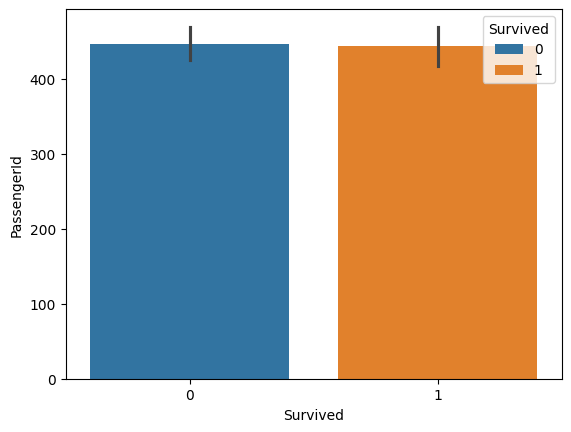

In [26]:
sns.barplot(data = titanic_data,x ="Survived",y= 'PassengerId',  hue = "Survived")

***Analyze survival based on passenger class***







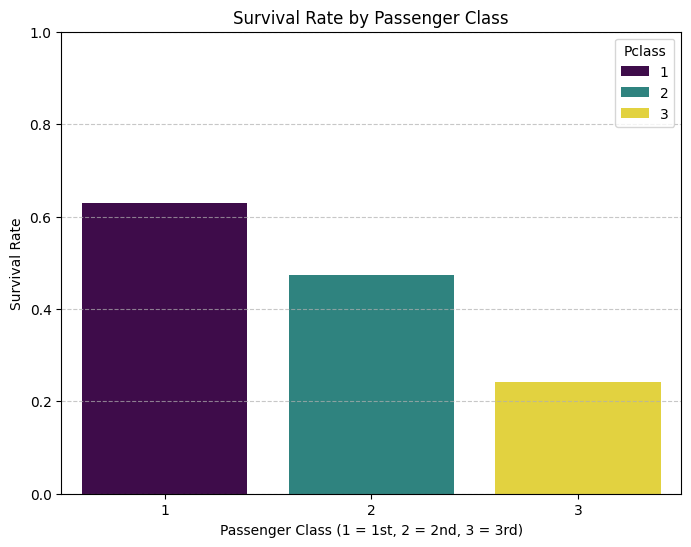

In [34]:
# Calculate survival rate by passenger class
survival_by_pclass = titanic_data.groupby('Pclass')['Survived'].mean().reset_index()

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Pclass', y='Survived', data=survival_by_pclass, hue='Pclass', palette='viridis', legend=True)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

***Analyze survival based on gender***

<Axes: xlabel='Sex', ylabel='Survived'>

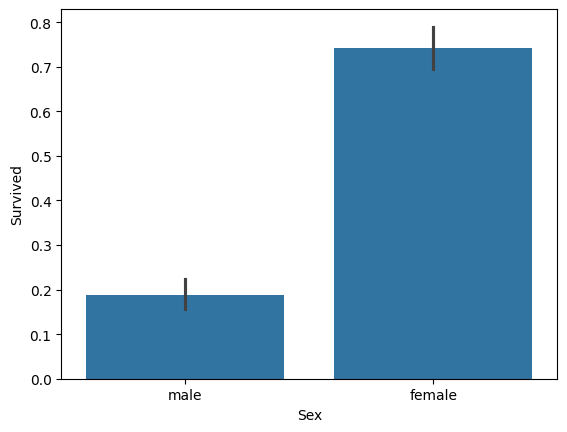

In [36]:
sns.barplot(data = titanic_data, x = 'Sex', y = 'Survived')


**Find the average age and average fare**

In [37]:
# Calculate the average age
average_age = titanic_data['Age'].mean()

# Calculate the average fare
average_fare = titanic_data['Fare'].mean()

print(f"Average Age: {average_age:.2f}")
print(f"Average Fare: {average_fare:.2f}")

Average Age: 29.70
Average Fare: 32.20


**Compare survival rates across age groups**

/tmp/ipykernel_686/3705976408.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_agegroup = titanic_data.groupby('AgeGroup')['Survived'].mean().reset_index()
/tmp/ipykernel_686/3705976408.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgeGroup', y='Survived', data=survival_by_agegroup, palette='viridis')


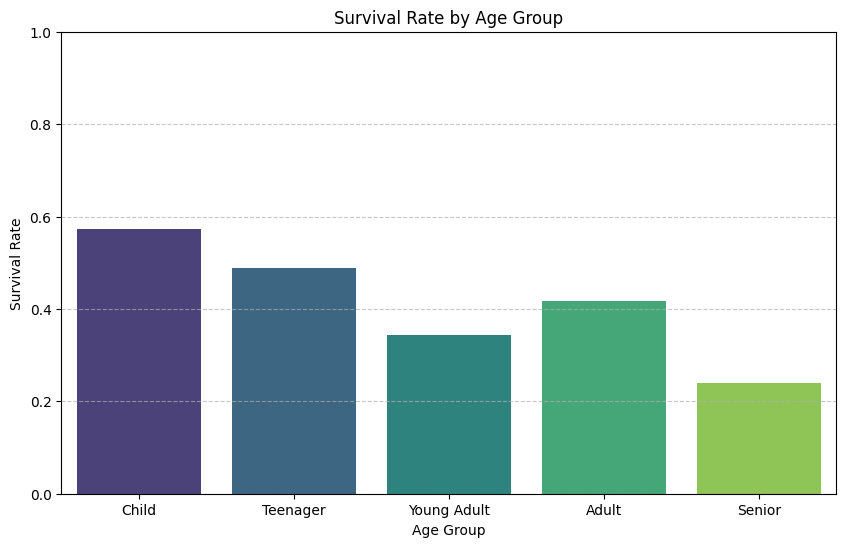

In [43]:
# Create age bins/groups
bins = [0, 12, 18, 35, 60, 80] # Define age group boundaries
labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'] # Define labels for age groups
titanic_data['AgeGroup'] = pd.cut(titanic_data['Age'], bins=bins, labels=labels, right=False)

# Calculate survival rate by AgeGroup
survival_by_agegroup = titanic_data.groupby('AgeGroup')['Survived'].mean().reset_index()

# Plotting the survival rate by AgeGroup
plt.figure(figsize=(10, 6))
sns.barplot(x='AgeGroup', y='Survived', data=survival_by_agegroup, palette='viridis')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

***Visualize fare distribution for survivors vs non-survivors***

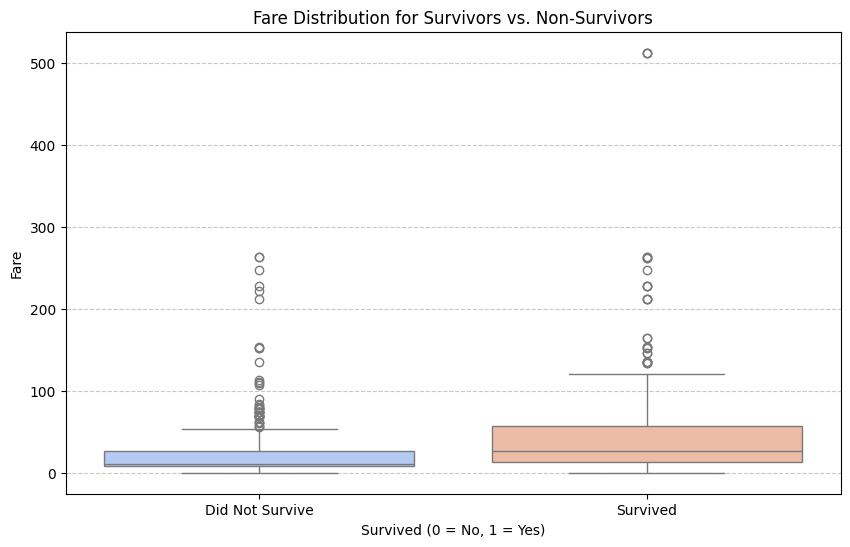

In [49]:
# Visualize fare distribution for survivors vs non-survivors using a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Survived', y='Fare', data=titanic_data, hue='Survived', palette='coolwarm', legend=False)
plt.title('Fare Distribution for Survivors vs. Non-Survivors')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Seaborn Plot Cheatsheet

Seaborn is a powerful Python data visualization library based on Matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics. Here's a quick guide to some of its most commonly used plots:

*   **`scatterplot()`**:
    *   **Best Use:** Visualizing the relationship between two continuous variables. Can show patterns, clusters, and outliers. Useful for checking correlations.
    *   **Example:** `sns.scatterplot(x='Fare', y='Age', data=titanic_data)`

*   **`lineplot()`**:
    *   **Best Use:** Showing trends over time or across an ordered category. Ideal for time series data or when connecting points implies a sequence.
    *   **Example:** If we had daily sales data, `sns.lineplot(x='Date', y='Sales', data=sales_data)`

*   **`histplot()`**:
    *   **Best Use:** Displaying the distribution of a single numerical variable. Shows the frequency of data points within specified bins. Can also show joint distributions of two variables with `x` and `y`.
    *   **Example:** `sns.histplot(x='Age', data=titanic_data, bins=20, kde=True)`

*   **`kdeplot()` (Kernel Density Estimate Plot)**:
    *   **Best Use:** Visualizing the probability density function of a continuous variable. Provides a smooth representation of the data's distribution, especially useful for comparing distributions.
    *   **Example:** `sns.kdeplot(x='Fare', data=titanic_data, hue='Survived')`

*   **`boxplot()`**:
    *   **Best Use:** Displaying the distribution of a continuous variable across different categories. Effectively shows median, quartiles, and outliers, making it excellent for comparing distributions between groups.
    *   **Example:** `sns.boxplot(x='Pclass', y='Age', data=titanic_data)` (as used in the previous step)

*   **`violinplot()`**:
    *   **Best Use:** Similar to a boxplot but also shows the kernel density estimate of the distribution. Provides a richer view of the data's shape than a boxplot, especially useful for multimodal distributions.
    *   **Example:** `sns.violinplot(x='Pclass', y='Age', data=titanic_data)`

*   **`barplot()`**:
    *   **Best Use:** Showing the central tendency (e.g., mean) of a numerical variable for different categories. Often includes confidence intervals.
    *   **Example:** `sns.barplot(x='Sex', y='Survived', data=titanic_data)` (as used previously)

*   **`countplot()`**:
    *   **Best Use:** Showing the counts of observations in each category. Essentially a bar plot for categorical data.
    *   **Example:** `sns.countplot(x='Pclass', data=titanic_data)`

*   **`heatmap()`**:
    *   **Best Use:** Visualizing matrix-like data, such as correlation matrices. Uses color intensity to represent values, making patterns easy to spot.
    *   **Example:** `sns.heatmap(titanic_data.corr(numeric_only=True), annot=True, cmap='coolwarm')`